### Overview:

A small startup is interested in developing a robust machine learning model that can successfully predict whether a customer will subscribe to a term deposit or not.

In order to acheive successful matric, We need to hit %81 or above accuracy by evaluating with 5-fold cross validation and reporting the average performance score.

Different models will be explored to determine whether the factors below could predict customers' subscription status.

age : age of customer (numeric)

job : type of job (categorical)

marital : marital status (categorical)

education (categorical)

default: has credit in default? (binary)

balance: average yearly balance, in euros (numeric)

housing: has a housing loan? (binary)

loan: has personal loan? (binary)

contact: contact communication type (categorical)

day: last contact day of the month (numeric)

month: last contact month of year (categorical)

duration: last contact duration, in seconds (numeric)

campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact).



### Data wrangling:
### Import Packages:

In [32]:
!pip install pycaret[full]

In [32]:
!python3 -m pip install --upgrade pip

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load data:

In [4]:
data = pd.read_csv("term-deposit-marketing-2020.csv")

### Explore the data:

In [5]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


In [7]:
data.describe(include='all')

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
count,40000.000000,40000,40000,40000,40000,40000.000000,40000,40000,40000,40000.000000,40000,40000.000000,40000.000000,40000
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,11,NaN,NaN,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,no
freq,NaN,9383,24386,20993,39191,NaN,24031,33070,24914,NaN,13532,NaN,NaN,37104
mean,40.544600,NaN,NaN,NaN,NaN,1274.277550,NaN,NaN,NaN,16.017225,NaN,254.824300,2.882175,NaN
std,9.641776,NaN,NaN,NaN,NaN,2903.769716,NaN,NaN,NaN,8.278127,NaN,259.366498,3.239051,NaN
min,19.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,NaN
25%,33.000000,NaN,NaN,NaN,NaN,54.000000,NaN,NaN,NaN,8.000000,NaN,100.000000,1.000000,NaN
50%,39.000000,NaN,NaN,NaN,NaN,407.000000,NaN,NaN,NaN,17.000000,NaN,175.000000,2.000000,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1319.000000,NaN,NaN,NaN,21.000000,NaN,313.000000,3.000000,NaN


### Cleaning, transforming and visualizing:

### Cleaning the data:

Let's have a closer look at the job,education and contact columns. their values need cleaning.

In [8]:
data["job"].unique()

array(['management', 'technician', 'entrepreneur', 'blue-collar',
       'unknown', 'retired', 'admin', 'services', 'self-employed',
       'unemployed', 'housemaid', 'student'], dtype=object)

In [9]:
data["education"].unique()

array(['tertiary', 'secondary', 'unknown', 'primary'], dtype=object)

In [10]:
data["contact"].unique()

array(['unknown', 'cellular', 'telephone'], dtype=object)

There are some missing values in 'job', 'education' and 'contact'.
We have to replace 'unknown' by 'nan' in order to find the missing values.
imputation is needed here.

In [11]:
data.replace('unknown', np.nan, inplace = True)
data.isnull().sum()


age              0
job            235
marital          0
education     1531
default          0
balance          0
housing          0
loan             0
contact      12765
day              0
month            0
duration         0
campaign         0
y                0
dtype: int64

In [12]:
data['y'].value_counts()

no     37104
yes     2896
Name: y, dtype: int64

We have umbalanced data (SMOTE Method is necessary)

Call replace() on the y column to replace 'yes' and 'no' by 1 and 0

In [13]:
data["y"] = data["y"].replace('yes', 1)
data["y"] = data["y"].replace('no', 0)
data['y'].unique()

array([0, 1])

#### Check the correlation for numerical features:

In [14]:
data.corr()["y"].sort_values(ascending=False)


y           1.000000
duration    0.461169
balance     0.030232
day        -0.006420
age        -0.020273
campaign   -0.040350
Name: y, dtype: float64

Duration feature has a strong positive correlation with the output.

#### Plot heatmap for categorical features:

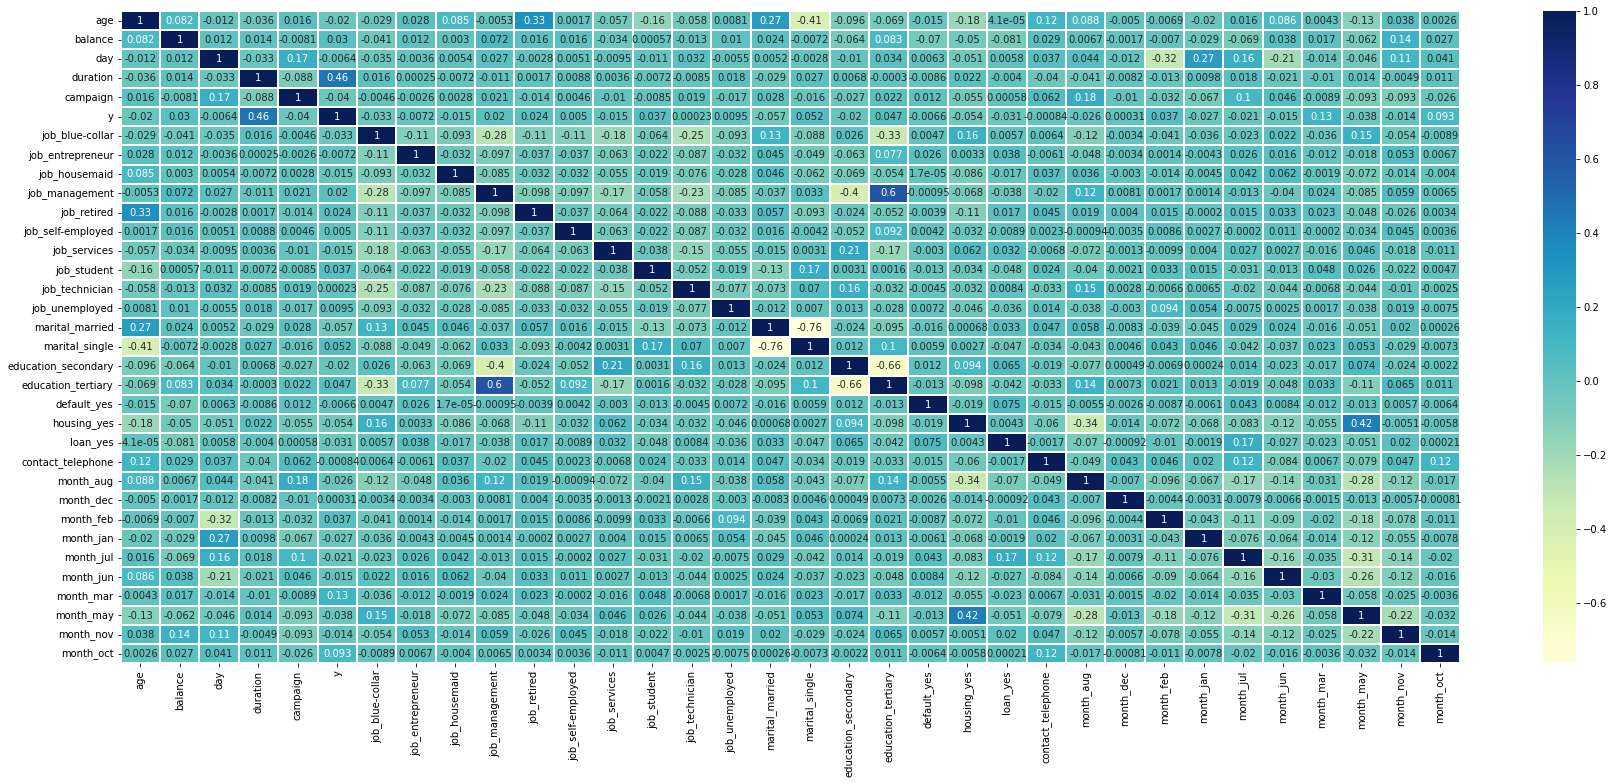

In [15]:
dfDummies = pd.get_dummies(data, drop_first=True)

plt.figure(figsize=(30,12))
sns.heatmap(dfDummies.corr(),linewidths=.1,cmap="YlGnBu", annot=True)
plt.yticks();

There is no multicollinearity.

### Checking distribution of numerical features:

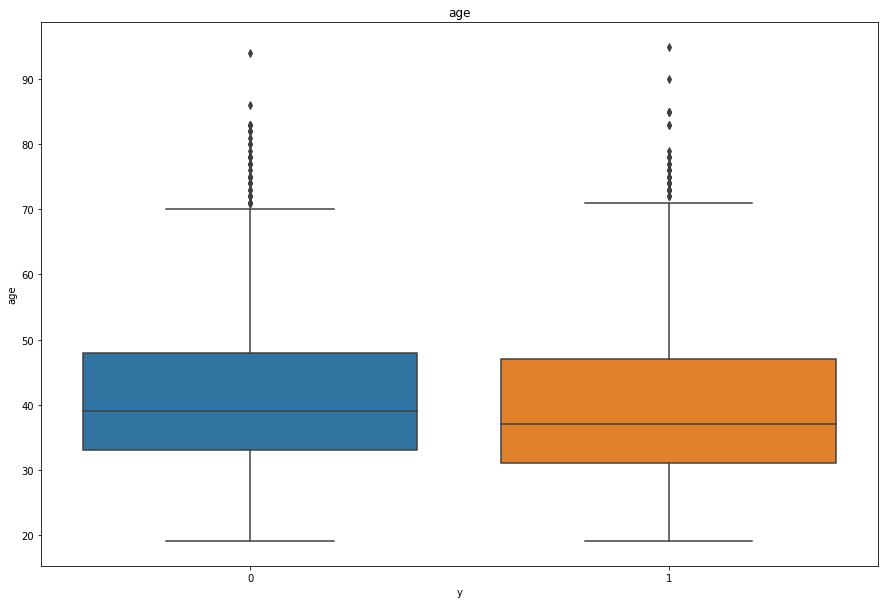

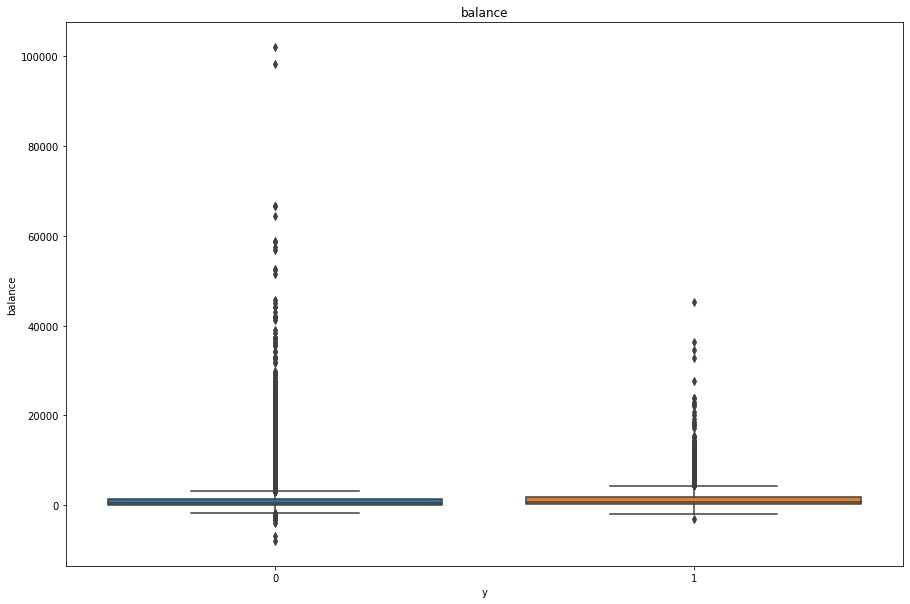

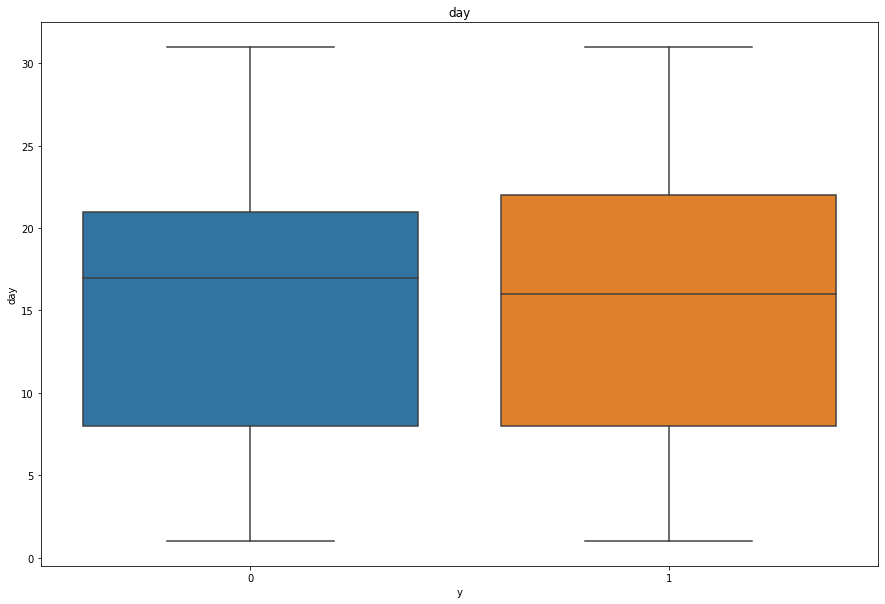

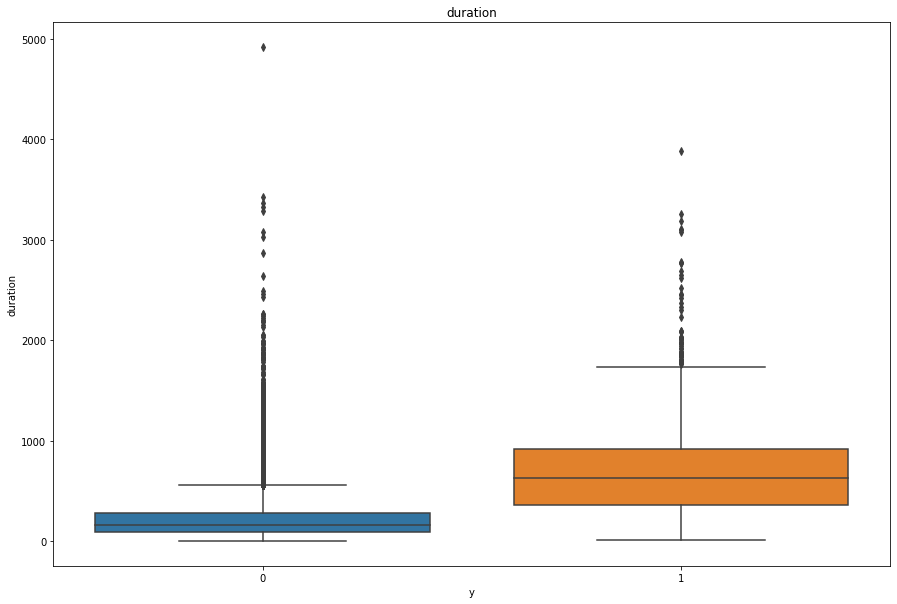

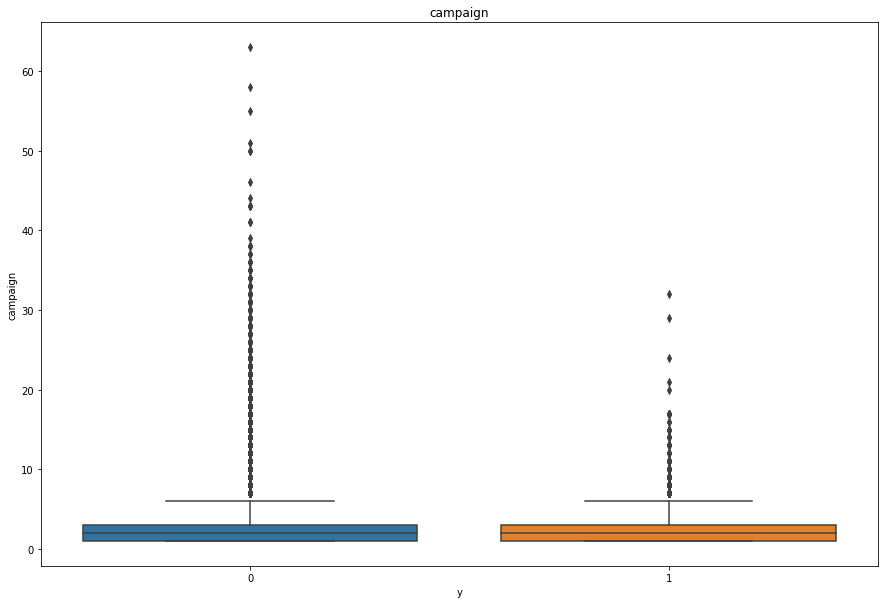

In [16]:
num_features = ['age', 'balance', 'day', 'duration', 'campaign']


for feature in num_features :
    plt.figure(figsize=(15,10))
    sns.boxplot(y=feature, x='y', data=data)
    plt.title(feature)
    plt.show()

In [17]:
data.groupby('y').mean()

,age,balance,day,duration,campaign
y,,,,,
0,40.599208,1249.752533,16.032072,221.408042,2.918688
1,39.844959,1588.495856,15.827003,682.958564,2.414365


- We noticed that the duration of a call plays a very important role on the subscription, As the longer a call lasts,the more likely the person is to subscribe to the term deposit.

- The average yearly balance for subscribers(1588 euro) is higher than non subscribers (1249 euro).



### Checking distribution of categorical features:

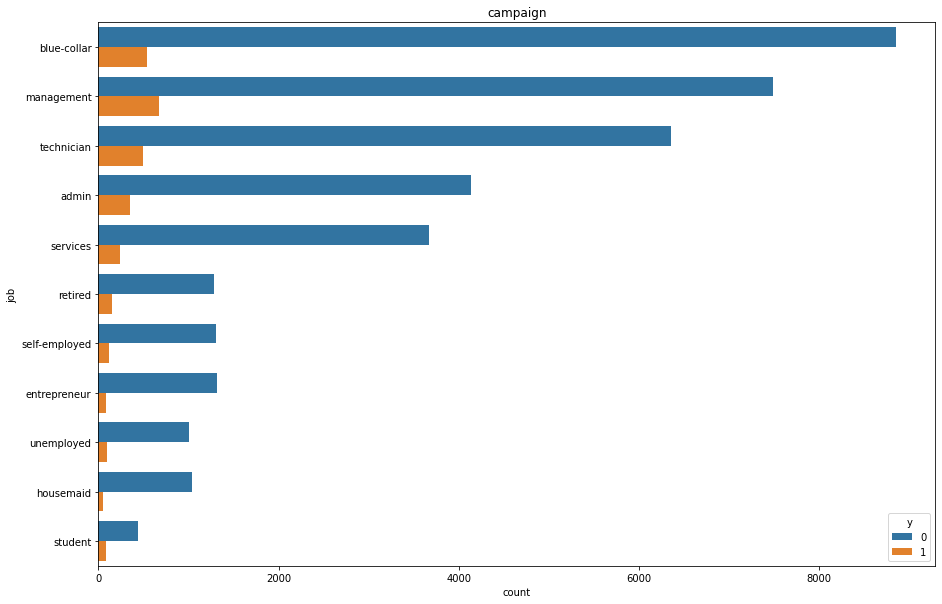

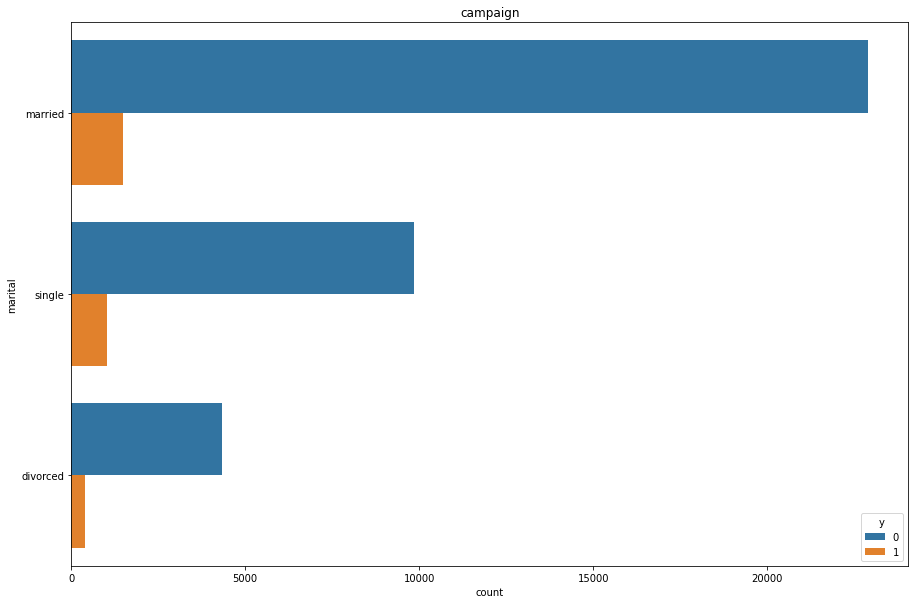

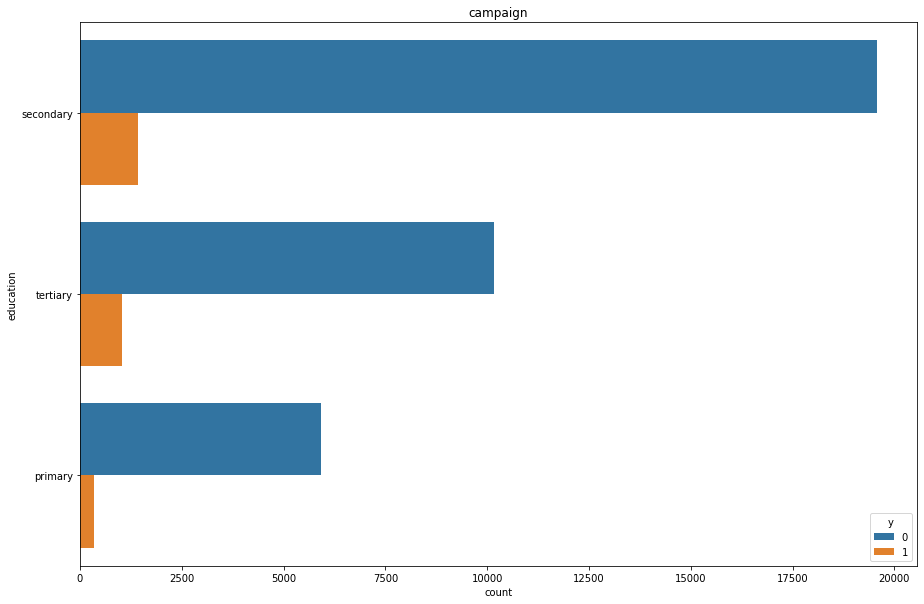

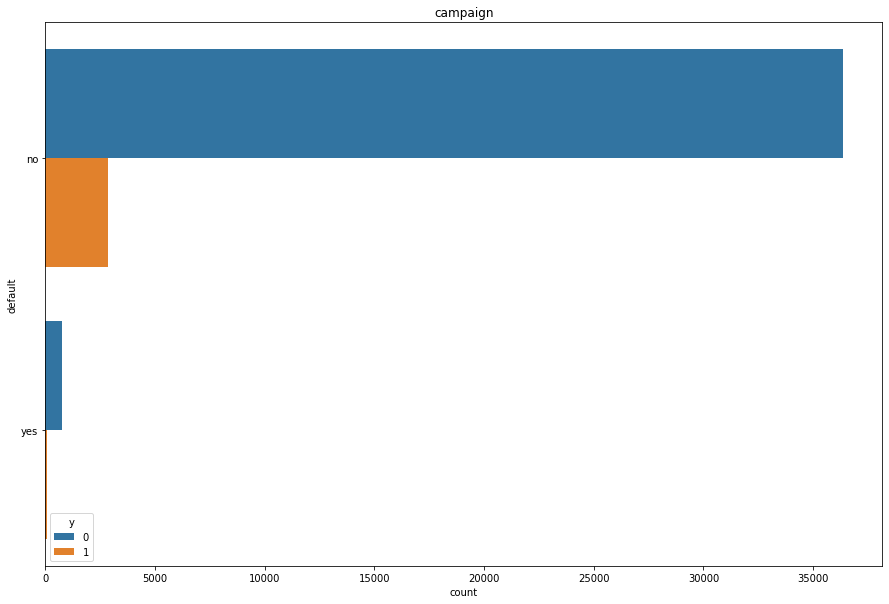

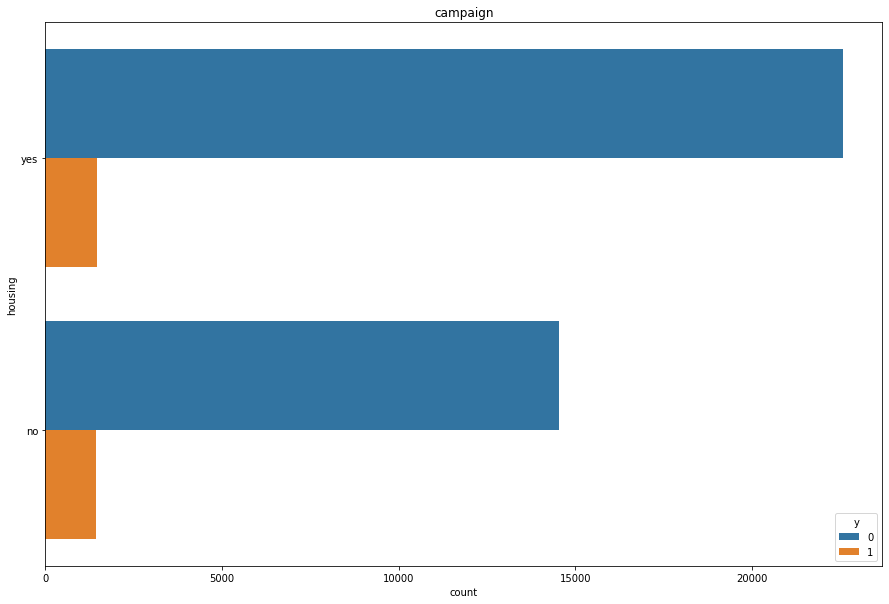

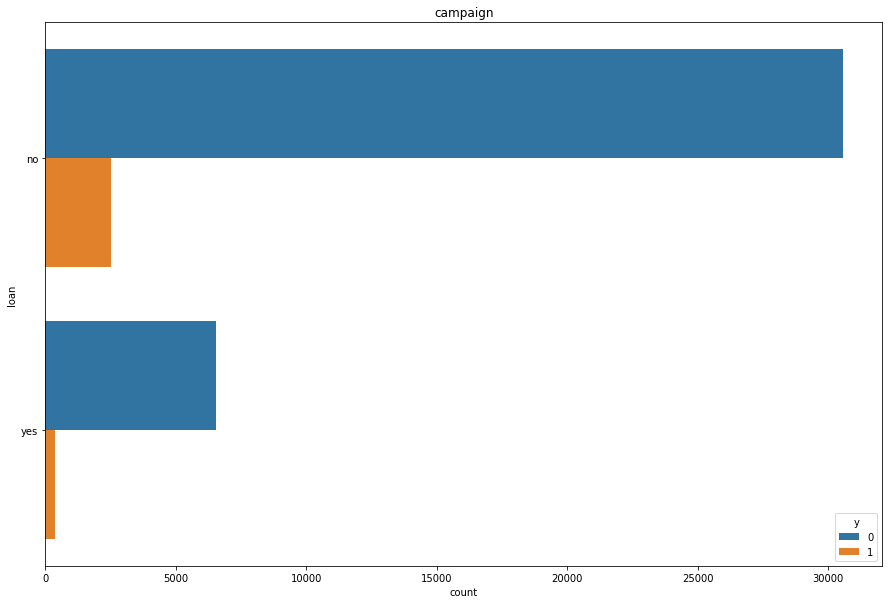

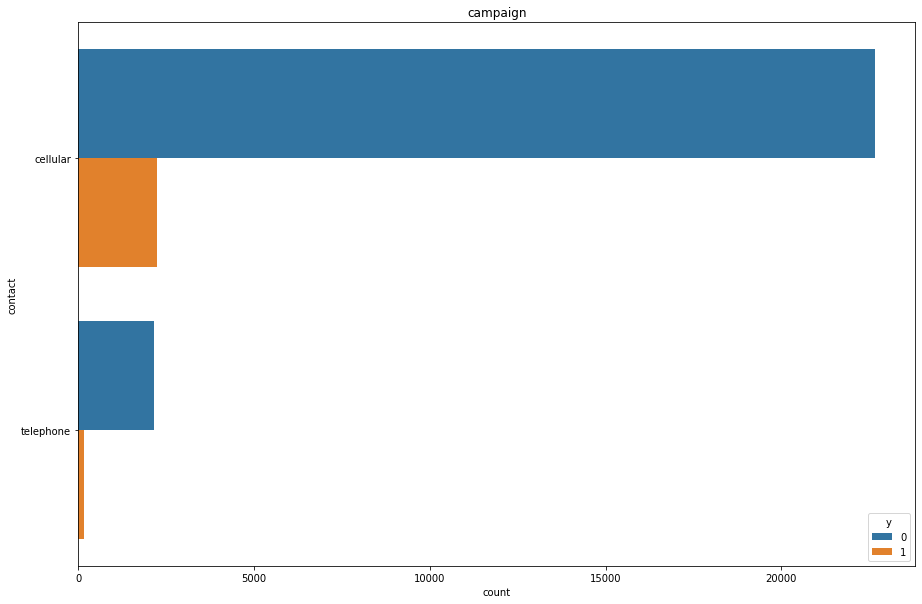

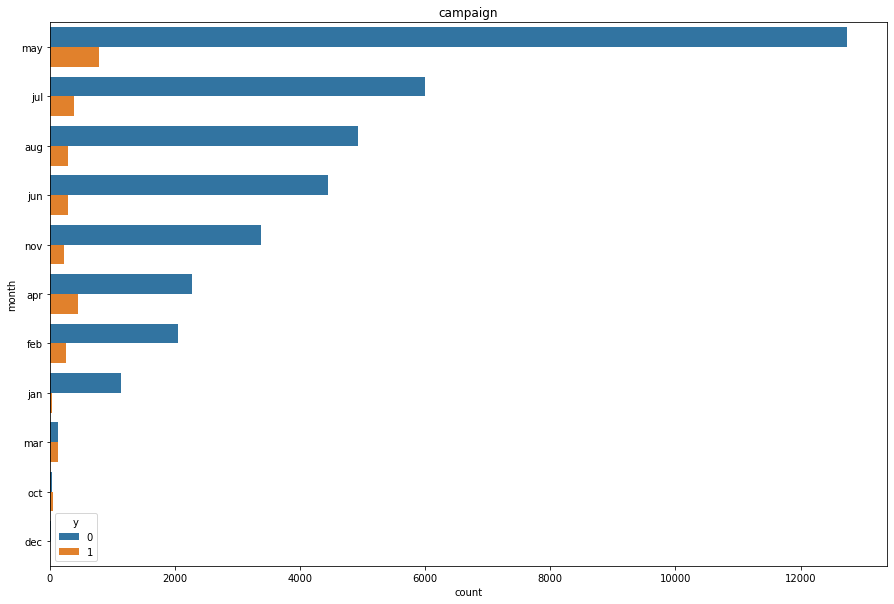

In [18]:
cat_features = ['job', 'marital', 'education', 'default','housing', 'loan', 'contact', 'month']

for i in cat_features:
    plt.figure(figsize=(15,10))
    ax = plt.subplot(1, 1, 1)
    arr = sns.countplot(data=data, y=data[i], order=data[i].value_counts().index, hue='y')
    legend_labels, _= ax.get_legend_handles_labels()
    plt.title(feature)
    plt.show()


### Plot the ratio (subscribers percentage ):

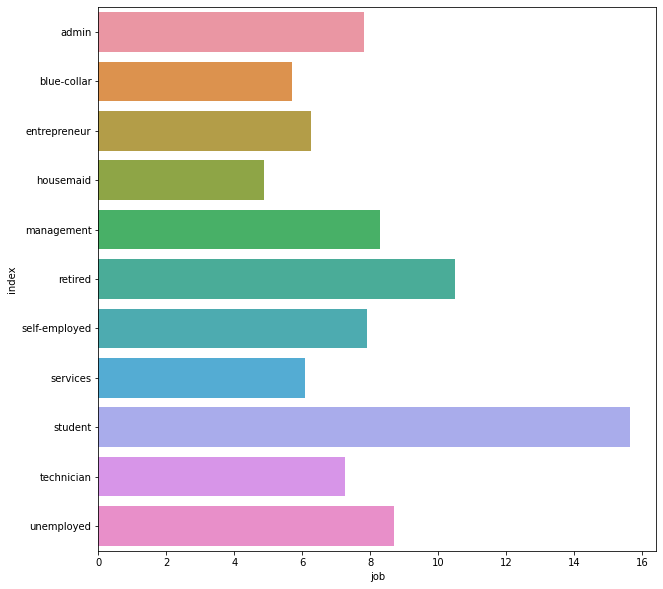

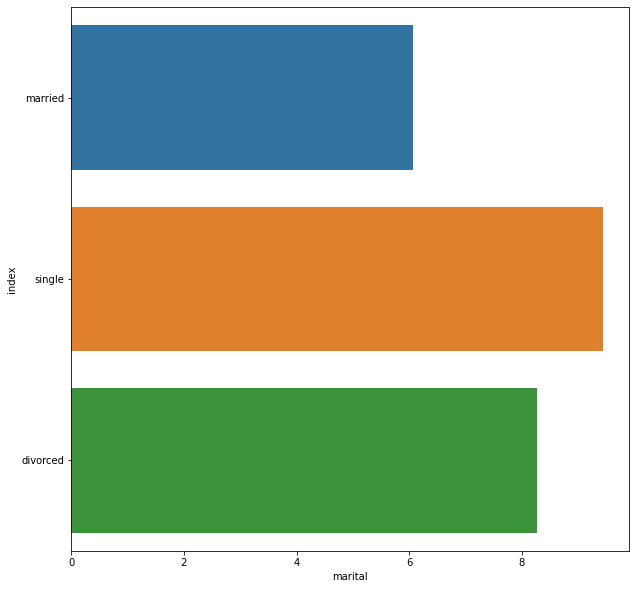

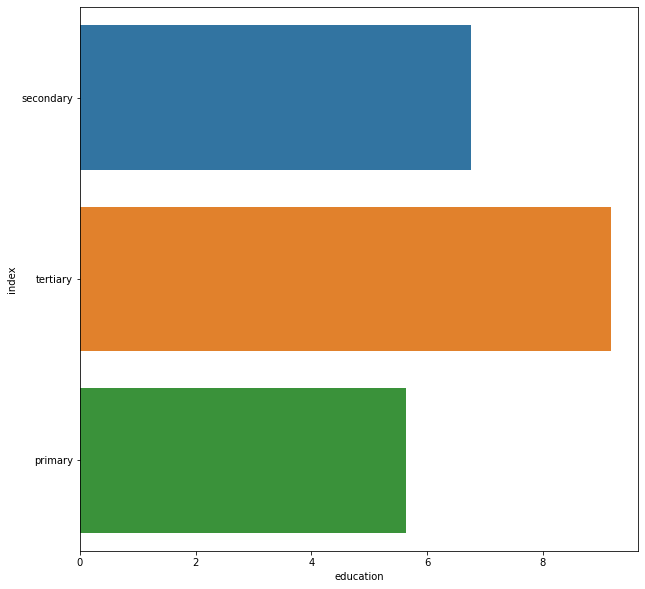

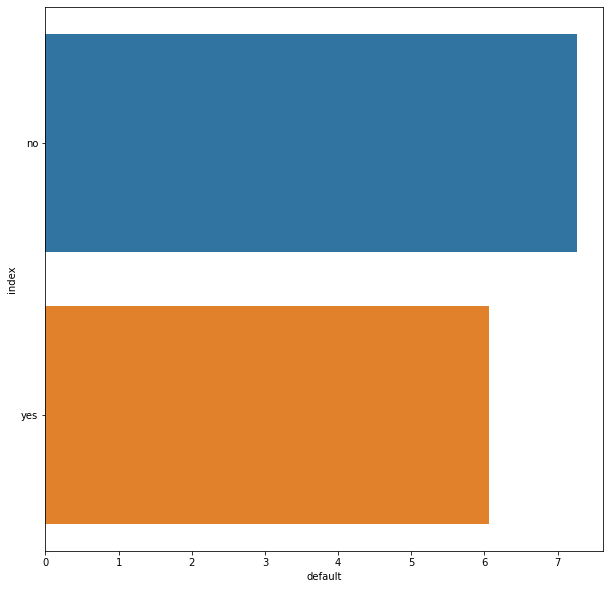

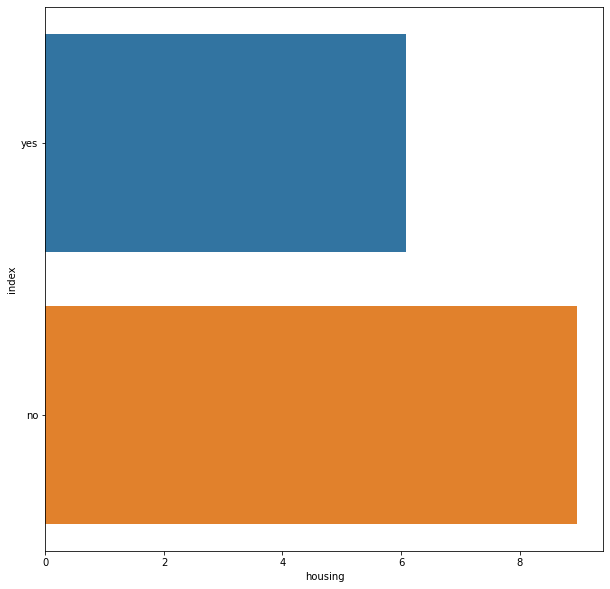

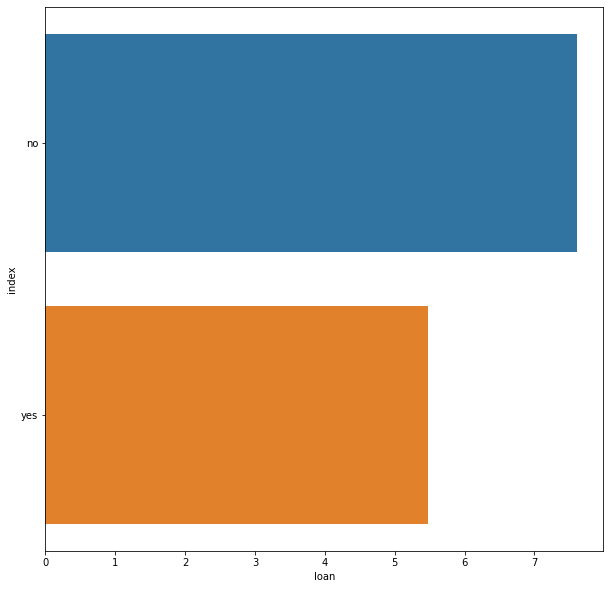

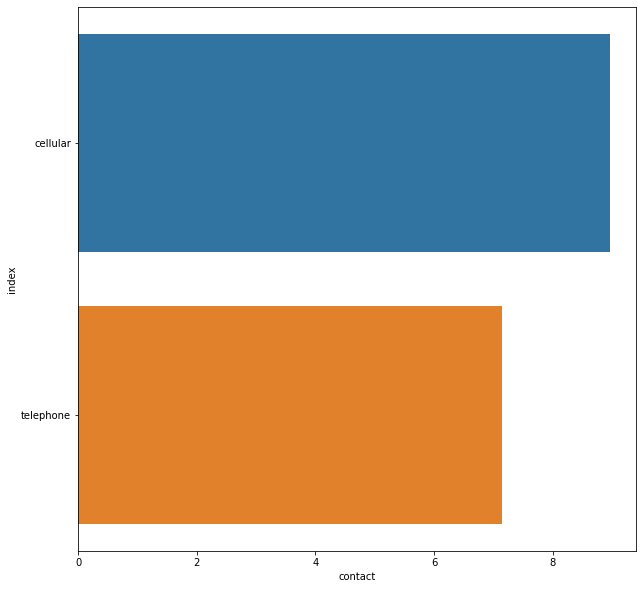

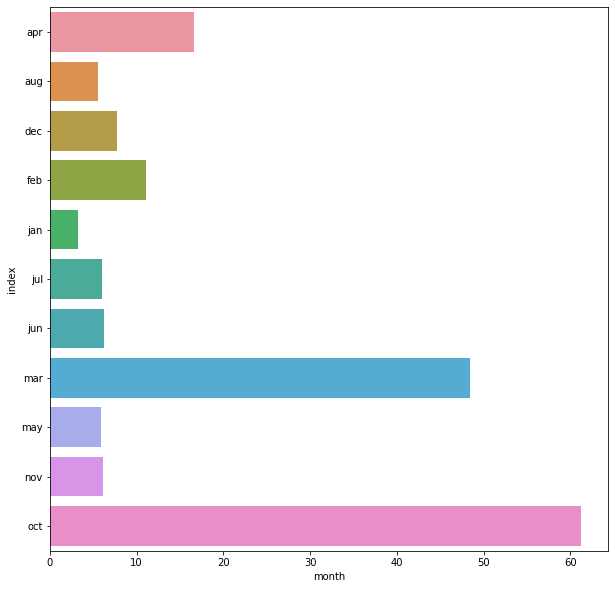

In [19]:
for i in cat_features:
    ratio = data[i].loc[(data.y == 1)].value_counts()/data[i].value_counts()*100
    ratio = ratio.reset_index()
    plt.subplots(nrows=1, ncols=1, figsize=(10,10))
    sns.barplot(data=ratio, y='index', x=i)
    plt.show()

There are some differences with the customer segment we are targeting versus those who have subscribed.

- for instance for job feature we have:  
blue-collar( are the main target client) we noticed few subscribers among them (only 6%) 
students (are not our main target client) show a higher subscription percentage (almost 17.5%)

- for marital feature:
We should be focusing more on single and divorced customers rather than married ones.

- for month feature:

for September there were no calls made at all.
While most calls were made in May (over 13000 calls) with few subscribers (5% subscribed rate)

instead we should make more calls in October and March as they have the highest subscription rates (over 50%)

### Data Preprocessing:

After taking all in consideration, We will use different methods to adjust our data such as:
Imputation, Transformation, clipping(Remove large outliers).

#### Create train sample:

In [20]:
df = data.sample(frac = 0.90 , random_state = 123)
df.shape

(36000, 14)

#### Create test sample:

In [21]:
df_unseen = data.drop(df.index)
df_unseen.shape

(4000, 14)

In [22]:
df.reset_index(inplace=True, drop= True)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,52,blue-collar,married,secondary,no,568,yes,no,telephone,17,apr,246,1,0
1,30,management,married,tertiary,no,112,yes,no,cellular,29,jan,464,2,0
2,27,unemployed,single,secondary,no,0,yes,no,NaN,27,may,185,2,0
3,33,management,married,tertiary,no,158,no,no,cellular,30,apr,169,2,0
4,46,admin,single,secondary,no,148,yes,no,cellular,5,may,85,4,0


In [23]:
df_unseen.reset_index(inplace=True, drop= True)
df_unseen.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
3995,40,technician,married,secondary,no,4298,no,no,cellular,2,jun,221,1,0
3996,56,retired,married,secondary,no,0,no,no,cellular,2,jun,71,3,0
3997,31,technician,single,tertiary,no,882,no,no,cellular,3,jun,411,1,1
3998,30,management,single,tertiary,no,3340,no,no,cellular,3,jun,238,3,1
3999,54,admin,divorced,secondary,no,200,no,no,cellular,3,jun,170,1,1


In [24]:
print('Data for modeling:' + str(df.shape))
print('Unseen Data for prediction:' + str(df_unseen.shape))

Data for modeling:(36000, 14)
Unseen Data for prediction:(4000, 14)


### Modelling:

#### Evaluating with 5-fold cross validation:

In [25]:
from pycaret.classification import *

exp1 = setup(df, target = 'y', session_id = 123,remove_multicollinearity = True,fold = 5, train_size= 0.90,
                multicollinearity_threshold = 0.95,use_gpu = True,categorical_features = cat_features,
                handle_unknown_categorical = True, normalize = True, transformation = True, fix_imbalance = True,
                ignore_low_variance = True, remove_outliers = True)

,Description,Value
0,session_id,123
1,Target,y
2,Target Type,Binary
3,Label Encoded,None
4,Original Data,"(36000, 14)"
5,Missing Values,True
6,Numeric Features,5
7,Categorical Features,8
8,Ordinal Features,False
9,High Cardinality Features,False


### Compare models:

In [26]:
best = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.9387,0.9458,0.4849,0.5461,0.5131,0.4806,0.4818,27.7440
dummy,Dummy Classifier,0.9333,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1940
et,Extra Trees Classifier,0.9317,0.9262,0.3413,0.4833,0.3998,0.3648,0.3711,5.3300
lightgbm,Light Gradient Boosting Machine,0.9317,0.9458,0.6129,0.4906,0.5448,0.5084,0.5122,2.3460
rf,Random Forest Classifier,0.9293,0.9369,0.4776,0.4703,0.4735,0.4357,0.4359,6.5180
dt,Decision Tree Classifier,0.9082,0.7232,0.5097,0.3658,0.4258,0.3774,0.3836,0.7520
gbc,Gradient Boosting Classifier,0.9013,0.9373,0.7848,0.3831,0.5148,0.4670,0.5044,10.8480
ada,Ada Boost Classifier,0.8923,0.9190,0.7483,0.3547,0.4812,0.4295,0.4670,2.9360
knn,K Neighbors Classifier,0.8656,0.8432,0.6631,0.2833,0.3970,0.3348,0.3734,10.8000
lr,Logistic Regression,0.8381,0.9199,0.8666,0.2743,0.4167,0.3509,0.4299,1.7140


### Create model:
### Train individual model:

In [27]:
catboost = create_model('catboost')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9399,0.9470,0.5158,0.5535,0.5340,0.5019,0.5023
1,0.9375,0.9464,0.5158,0.5327,0.5241,0.4906,0.4907
2,0.9371,0.9450,0.4745,0.5328,0.5019,0.4685,0.4694
3,0.9405,0.9466,0.4769,0.5648,0.5172,0.4857,0.4877
4,0.9384,0.9443,0.4415,0.5468,0.4885,0.4562,0.4591
Mean,0.9387,0.9458,0.4849,0.5461,0.5131,0.4806,0.4818
Std,0.0013,0.0010,0.0282,0.0124,0.0161,0.0163,0.0155


### Predict our model on test Sample:

In [28]:
unseen_pred = predict_model (catboost, data = df_unseen)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,CatBoost Classifier,0.9358,0.9341,0.4800,0.5878,0.5284,0.4943,0.4973


### Plot ROC curves:

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


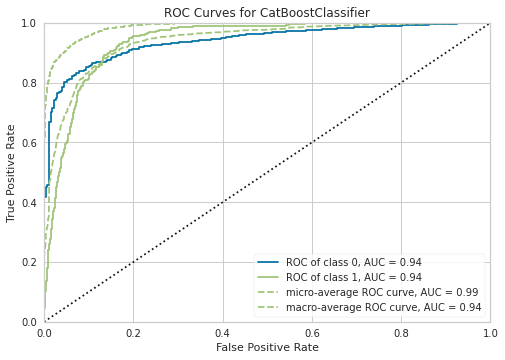

In [29]:
plot_model(catboost)

### Confusion Matrix:

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


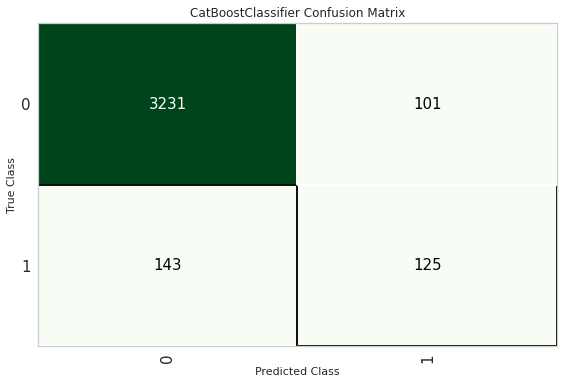

In [30]:
plot_model(catboost , plot = 'confusion_matrix')

In [31]:
!pip install shap

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


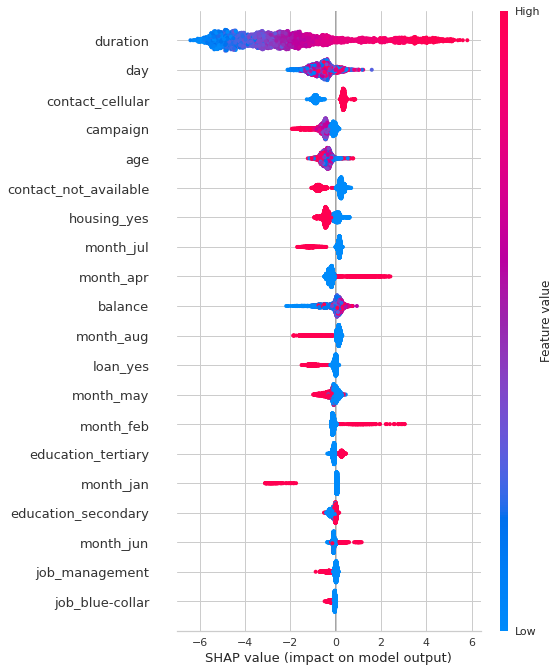

In [32]:
import shap

interpret_model(catboost)


### Conclusion:

We will choose the best performing model(CatBoost Classifier), As it has a 5 fold cross validation accuracy of 93.87% with a test accuracy of 93.58%.

We noticed that the longer the duration of a call has a high correlation with how likely a person is to subscribe. 

From shap library, month feature has high importance as well.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=61dbc9c3-18ec-41bd-a559-3e0075f05409' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>